In [51]:
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
from scipy import integrate
import os
import time
import datetime

##### gamma=0.1810 #####
##### nu=-0.1800 #####
##### nu=-0.1900 #####
##### nu=-0.2000 #####
##### nu=-0.2100 #####
##### nu=-0.2200 #####


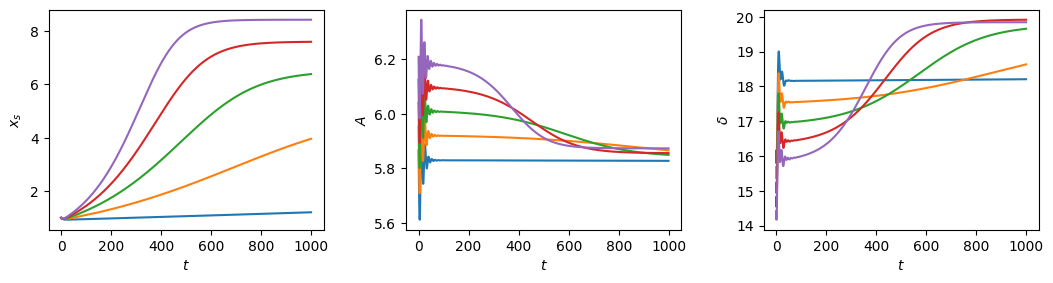

In [52]:
disco = r'D:/'
working_directory = disco + r'simulation_data/pdnlS/alpha=6.5000/beta=1.0000' #COLOCAR DIRECCION CORRECTA
directories = [name for name in os.listdir(working_directory) if os.path.isdir(os.path.join(working_directory, name))]
for directory in directories:
    print("##### " + str(directory) + " #####")
    working_subdirectory = working_directory + "/" + directory + "/mu=0.1000"
    subdirectories = [name for name in os.listdir(working_subdirectory) if os.path.isdir(os.path.join(working_subdirectory, name))]
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 2.5))
    for subdirectory in subdirectories:
        print("##### " + str(subdirectory) + " #####")
        current_directory = working_subdirectory + "/" + subdirectory
        U_real = np.loadtxt(current_directory + '/field_real.txt', delimiter=',')
        U_imag = np.loadtxt(current_directory + '/field_img.txt', delimiter=',')
        x_grid = np.loadtxt(current_directory + '/X.txt', delimiter=',')
        t_grid = np.loadtxt(current_directory + '/T.txt', delimiter=',')
        U = U_real + 1j * U_imag
        U_mod = np.abs(U)
        N = integrate.simpson(U_mod ** 2, x_grid)
        center = integrate.simpson(x_grid * U_mod ** 2, x_grid) / N
        width = []
        for i in range(len(t_grid)):
            width_i = integrate.simpson((x_grid - center[i]) ** 2 * U_mod[i, :] ** 2, x_grid) / N[i]
            width.append(width_i)
        width = np.array(width)
        ax[0].plot(t_grid, center)
        ax[0].set_xlabel(r"$t$")
        ax[0].set_ylabel(r"$x_s$")

        ax[1].plot(t_grid, N)
        ax[1].set_xlabel(r"$t$")
        ax[1].set_ylabel(r"$A$")

        ax[2].plot(t_grid, width)
        ax[2].set_xlabel(r"$t$")
        ax[2].set_ylabel(r"$\delta$")
    fig.subplots_adjust(wspace=0.3, hspace=0.0, left=0.0, bottom=0.0)
    plt.show() #SUGERENCIA: GUARDAR ESTE PLOT EN CADA WORKING SUBDIRECTORY, AL IGUAL QUE LOS DATOS OBTENIDOS DE CENTROS, AMPLITUD Y ANCHO E UN .TXT